[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flexfengfeng/dsai-m3-ml-genai/blob/main/L08-computer-vision/notebooks/02_convolutions_intuition.ipynb)

# L08 · NB 02 — Convolutions, by hand

> *Before we let PyTorch learn kernels for us, let's run a few by hand and watch what they do.*

This notebook is fully manual. We will:

1. Pull a Fashion-MNIST image
2. Build three hand-crafted 3×3 kernels (edge detector, blur, sharpen)
3. Convolve each kernel with the image and look at the output feature maps
4. Build a stack of two kernels and see what compositionality looks like
5. Connect the manual operation to `nn.Conv2d`

This is the **why** behind CNNs. By the end you should be able to look at a kernel and predict its feature map.

## 1 · Setup & one image

Selected image: Coat  | shape: (28, 28)


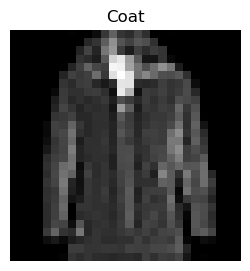

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.datasets import FashionMNIST

torch.set_num_threads(1)
torch.manual_seed(42)

train_ds = FashionMNIST(root='data/fmnist', train=True, download=True, transform=T.ToTensor())
CLASSES = train_ds.classes

# Grab one good sample of a "Coat" (class 4) — has visible vertical edges
idx = next(i for i, (_, y) in enumerate(train_ds) if y == 4)
img_tensor, label = train_ds[idx]
img_np = img_tensor.squeeze().numpy()  # (28, 28)

print(f"Selected image: {CLASSES[label]}  | shape: {img_np.shape}")
plt.figure(figsize=(3, 3))
plt.imshow(img_np, cmap='gray')
plt.title(CLASSES[label])
plt.axis('off')
plt.show()

## 2 · Three hand-crafted kernels

A kernel is just 9 numbers in a 3×3 grid. The numbers determine **what pattern the kernel responds to**.

In [2]:
edge = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
], dtype=np.float32)

blur = np.ones((3, 3), dtype=np.float32) / 9.0  # box blur

sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0],
], dtype=np.float32)

print('Edge kernel:'); print(edge)
print('Blur kernel:'); print(blur)
print('Sharpen kernel:'); print(sharpen)

Edge kernel:
[[-1. -1. -1.]
 [-1.  8. -1.]
 [-1. -1. -1.]]
Blur kernel:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
Sharpen kernel:
[[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]


**Why these work:**

- **Edge** — centre pixel weighted +8, neighbours -1. On a flat region the sum is 0. On an edge (centre different from neighbours), the sum is large. Highlights edges.
- **Blur** — average of the 9 pixels. Smooths out high-frequency variation.
- **Sharpen** — emphasises the centre relative to its top/bottom/left/right neighbours. Increases local contrast.

## 3 · Manual convolution

Let's write convolution from scratch — no library magic. For each output pixel, multiply the kernel element-wise with the corresponding 3×3 patch of the image and sum.

In [3]:
def conv2d_manual(image, kernel):
    """Naive 2D convolution. Returns an output the same size as input (zero-padded)."""
    h, w = image.shape
    kh, kw = kernel.shape
    pad = kh // 2
    padded = np.pad(image, pad, mode='constant', constant_values=0)
    out = np.zeros_like(image, dtype=np.float32)
    for i in range(h):
        for j in range(w):
            patch = padded[i:i+kh, j:j+kw]
            out[i, j] = (patch * kernel).sum()
    return out

edge_map    = conv2d_manual(img_np, edge)
blur_map    = conv2d_manual(img_np, blur)
sharpen_map = conv2d_manual(img_np, sharpen)
print('Output shapes:', edge_map.shape, blur_map.shape, sharpen_map.shape)

Output shapes: (28, 28) (28, 28) (28, 28)


## 4 · Look at the feature maps

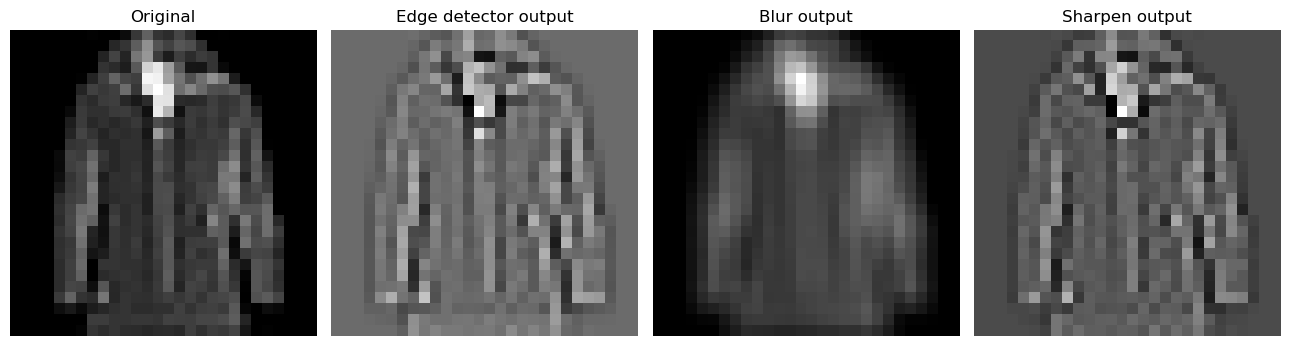

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4))
axes[0].imshow(img_np, cmap='gray');    axes[0].set_title('Original')
axes[1].imshow(edge_map, cmap='gray');  axes[1].set_title('Edge detector output')
axes[2].imshow(blur_map, cmap='gray');  axes[2].set_title('Blur output')
axes[3].imshow(sharpen_map, cmap='gray');axes[3].set_title('Sharpen output')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

See it? The **same 9 numbers** turned a coat photo into "where are the edges?", "smoothed version", and "high-contrast version." That's the whole magic of convolution.

A CNN doesn't hard-code these kernels — it **learns them from data**. But the kernels it learns look a lot like edge detectors in the early layers, and combinations of edges (corners, curves) deeper down.

## 5 · From manual to `nn.Conv2d`

Now let's do the same thing with PyTorch. We'll create a `Conv2d` layer, manually set its weights to our edge kernel, and verify we get the same output.

In [5]:
# nn.Conv2d expects weights of shape (out_channels, in_channels, kH, kW)
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1, bias=False)
with torch.no_grad():
    conv.weight.copy_(torch.tensor(edge).view(1, 1, 3, 3))

# Run the image through it
img_batched = img_tensor.unsqueeze(0)   # (1, 1, 28, 28)
with torch.no_grad():
    out = conv(img_batched).squeeze().numpy()

# Compare to our manual result
diff = np.abs(out - edge_map).max()
print(f"Max absolute difference between manual and nn.Conv2d output: {diff:.6f}")
print(f"They agree to {'machine precision' if diff < 1e-5 else 'wrong'}.")

Max absolute difference between manual and nn.Conv2d output: 0.000001
They agree to machine precision.


**Same result.** `nn.Conv2d` is just our hand-rolled function, accelerated and learnable.

## 6 · Multiple output channels

A real CNN doesn't learn one kernel — it learns *many*. A single `Conv2d(in_channels=1, out_channels=16, kernel_size=3)` layer learns 16 different 3×3 kernels in parallel, each producing its own feature map.

Layer parameters: 160
Feature maps shape: torch.Size([16, 28, 28])


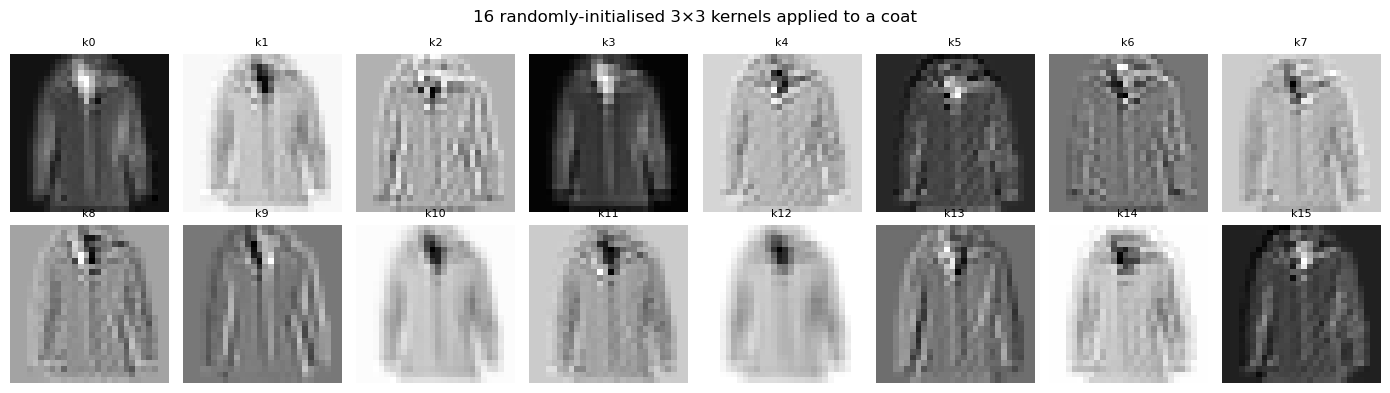

In [6]:
multi_conv = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
# Default initialisation = random weights (this is what training would learn)
with torch.no_grad():
    feature_maps = multi_conv(img_batched).squeeze(0)  # (16, 28, 28)

print(f"Layer parameters: {sum(p.numel() for p in multi_conv.parameters()):,}")
print(f"Feature maps shape: {feature_maps.shape}")

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[i].numpy(), cmap='gray')
    ax.set_title(f'k{i}', fontsize=8)
    ax.axis('off')
plt.suptitle('16 randomly-initialised 3×3 kernels applied to a coat')
plt.tight_layout()
plt.show()

These look random because the kernels are random. After training on Fashion-MNIST, these would specialise — some would detect horizontal edges, some vertical, some textures, some specific shapes. **Training = learning the kernels.**

## 7 · Pooling — shrinking the feature map

After a conv layer, we usually downsample. **Max pooling** with a 2×2 window halves the height and width, keeping only the strongest activation in each block. This gives two benefits:

1. Smaller feature maps → less compute, fewer parameters in the next layer
2. **Translation tolerance** — small shifts in the input don't change the pooled output

Before pool: torch.Size([16, 28, 28])
After  pool: torch.Size([16, 14, 14])


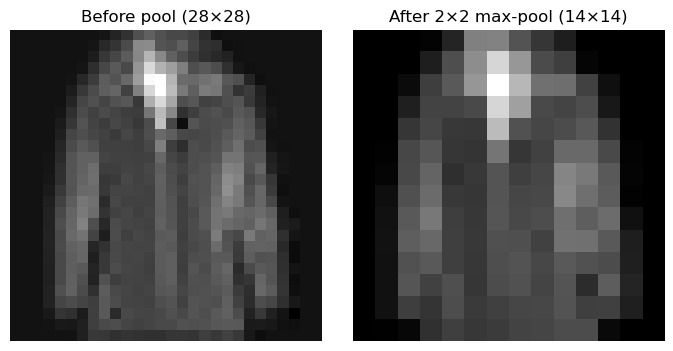

In [7]:
pool = nn.MaxPool2d(kernel_size=2)
with torch.no_grad():
    pooled = pool(feature_maps.unsqueeze(0)).squeeze(0)
print(f"Before pool: {feature_maps.shape}")
print(f"After  pool: {pooled.shape}")

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(feature_maps[0].numpy(), cmap='gray'); axes[0].set_title('Before pool (28×28)')
axes[1].imshow(pooled[0].numpy(),       cmap='gray'); axes[1].set_title('After 2×2 max-pool (14×14)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

Half the resolution, same essential information. Repeat a few times and you go from `28×28` down to `7×7` while the number of feature channels grows — `1 → 16 → 32 → 64`. The pattern is **shrink in space, grow in channels**.

## 8 · The CNN block — recap

The standard block we'll use in NB 03 is just three operations:

```
Conv2d  →  ReLU  →  MaxPool2d
```

That's the entire pattern. Stack 2-3 of these blocks, flatten the result, run it through a linear classifier head, and you have a working CNN.

Let's go build one.

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## E1 · What happens if you remove padding?

Without padding, a 3×3 kernel shrinks the output by 2 pixels in each dimension. Run two convs in a row and you lose 4. That's why we set `padding=1` for 3×3 kernels — it keeps the output size identical.

In [8]:
no_pad = nn.Conv2d(1, 1, kernel_size=3, padding=0)
with torch.no_grad():
    out = no_pad(img_batched)
print(f"Input shape : {img_batched.shape}")
print(f"Output (no padding): {out.shape}  # 28 - 2 = 26")

Input shape : torch.Size([1, 1, 28, 28])
Output (no padding): torch.Size([1, 1, 26, 26])  # 28 - 2 = 26


## E2 · Try a different kernel: vertical edge detector

The Sobel vertical-edge kernel responds to changes from left → right brightness:

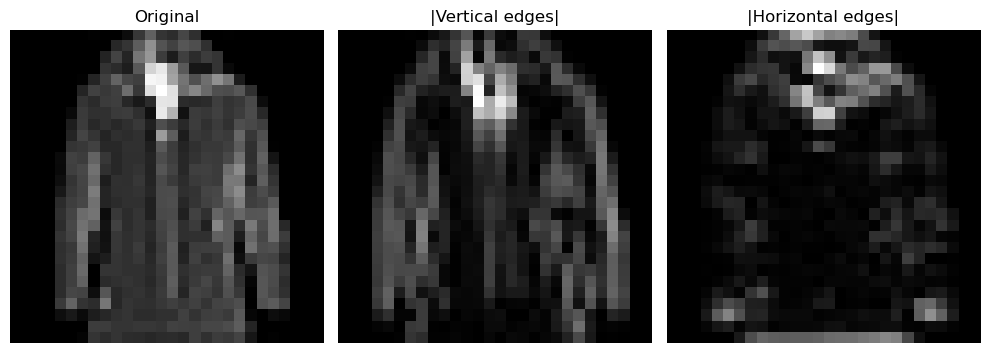

In [9]:
sobel_v = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=np.float32)

sobel_h = sobel_v.T  # horizontal edges

vmap = conv2d_manual(img_np, sobel_v)
hmap = conv2d_manual(img_np, sobel_h)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
axes[0].imshow(img_np, cmap='gray');           axes[0].set_title('Original')
axes[1].imshow(np.abs(vmap), cmap='gray');     axes[1].set_title('|Vertical edges|')
axes[2].imshow(np.abs(hmap), cmap='gray');     axes[2].set_title('|Horizontal edges|')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

Different kernel, different feature map. A CNN's first layer typically learns a bank of edge detectors at various angles. Subsequent layers combine these into corners and shapes.

This compositional structure is what makes deep CNNs work — and what motivated the entire deep-learning revolution in computer vision around 2012.